# Part 1

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import numpy as np
import copy
import time
import torch.optim as optim

In [3]:
model = models.resnet18(pretrained=True)
model.eval() # set to evaluation mode

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
intermediate_layer_name = "Layer2 - Block1 - Conv1" # stage 2 , first block , first conv
intermediate_weights = model.layer2[0].conv1.weight

# final layer
final_layer_name = "Final FC Layer"
final_weights = model.fc.weight

In [5]:
def analyze_layer_with_svd(weight_tensor, layer_name):
    W = weight_tensor.detach().cpu().numpy()
    start_shape = W.shape
    if len(start_shape) > 2:
        W = W.reshape(start_shape[0], -1) # (Out_Channels, In_Channels * Kernel * Kernel)
    print(f"start shape: {start_shape} , new shape: {W.shape}")


    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    eigenvalues = S ** 2
    total_variance = np.sum(eigenvalues)
    explained_variance_ratio = eigenvalues / total_variance
    cumulative_variance = np.cumsum(explained_variance_ratio)

    k_95 = np.argmax(cumulative_variance >= 0.95) + 1
    total_components = len(S)
    percent_kept = (k_95 / total_components) * 100

    print(f"total singular values: {total_components}")
    print(f"components needed for 95% variance: {k_95}")
    print(f"percentage of components kept: {percent_kept:.2f}%")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(S)
    plt.title(f'singular values , {layer_name}')
    plt.xlabel('component index')
    plt.ylabel('singular value')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(cumulative_variance)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
    plt.axvline(x=k_95, color='g', linestyle='--', label=f'k={k_95}')
    plt.title(f'cumulative explained variance: {layer_name}')
    plt.xlabel('number of components')
    plt.ylabel('cumulative variance')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

start shape: (128, 64, 3, 3) , new shape: (128, 576)
total singular values: 128
components needed for 95% variance: 94
percentage of components kept: 73.44%


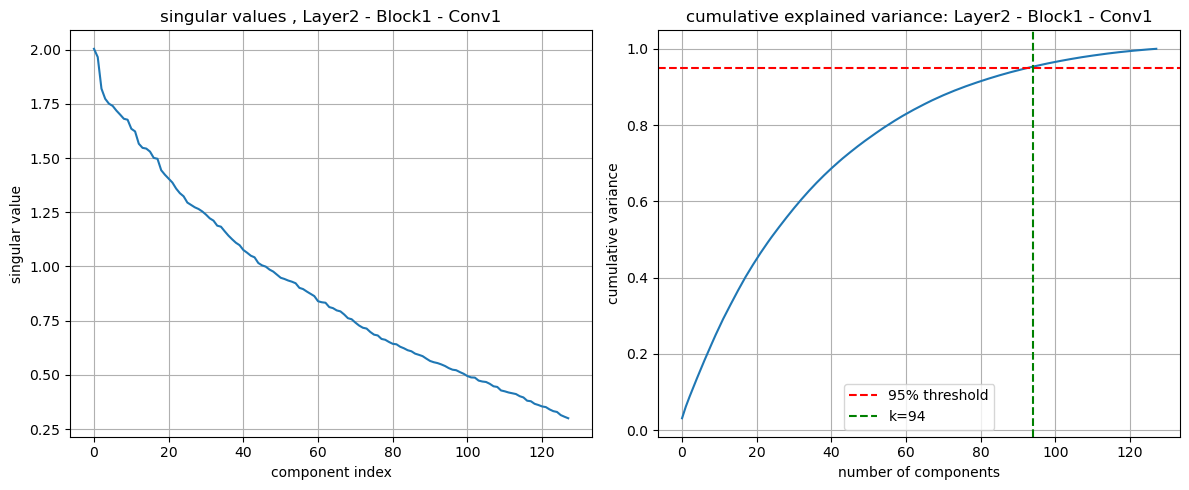

In [6]:
analyze_layer_with_svd(intermediate_weights, intermediate_layer_name)

start shape: (1000, 512) , new shape: (1000, 512)
total singular values: 512
components needed for 95% variance: 291
percentage of components kept: 56.84%


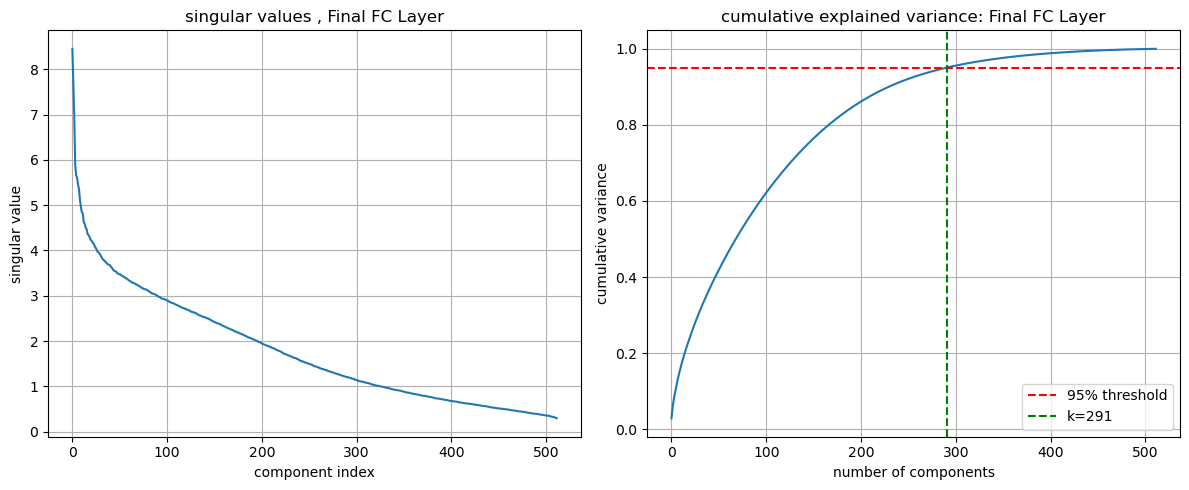

In [7]:
analyze_layer_with_svd(final_weights, final_layer_name)

# part 2

In [8]:
# load CIFAR-10
transform = transforms.Compose([
    transforms.Resize(224), # resnet expects 224x224
    transforms.ToTensor(),
])

test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# we use first 15 batches of this data for test , next 100 batches for train

Files already downloaded and verified


In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def evaluate_model(model, loader, device='cpu'):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            if i > 15: break # limit to 32*15=480 images for quick testings
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    return accuracy

# function to replace linear layer using svd
def compress_linear_layer(layer, keep_ratio):
    W = layer.weight.data.cpu().numpy()
    bias = layer.bias.data if layer.bias is not None else None
    out_features, in_features = W.shape

    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    
    full_rank = len(S)
    k = int(full_rank * keep_ratio)
    
    print(f"compressing layer, Rank {full_rank} to {k} (ratio: {keep_ratio})")
    
    # keep top k components
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    
    # W_approx = U_k * S_k * Vt_k
    # W1 (in) = sqrt(S_k) * Vt_k   
    # W2 (out) = U_k * sqrt(S_k)    
    
    sqrt_S_k = np.sqrt(S_k)
    W1 = np.dot(sqrt_S_k, Vt_k) # (k , in)
    W2 = np.dot(U_k, sqrt_S_k) # (out , k)
    
    # layer 1: in -> k (No bias)
    layer1 = nn.Linear(in_features, k, bias=False)
    layer1.weight.data = torch.from_numpy(W1).float()
    
    # layer 2: k -> out (with original bias)
    layer2 = nn.Linear(k, out_features, bias=(bias is not None))
    layer2.weight.data = torch.from_numpy(W2).float()
    if bias is not None:
        layer2.bias.data = bias
        
    return nn.Sequential(layer1, layer2)

In [10]:
# train model for some epochs to recover accuracy.
def fine_tune_model(model, train_loader, epochs=3, device='cuda'):
    model.to(device)
    model.train()
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    
    print(f"starting finetuning for {epochs} epochs...")
    
    for epoch in range(epochs):
        running_loss = 0.0
        # limit to 100 batches for speed
        for i, (inputs, labels) in enumerate(train_loader):
            # dont use test data
            if i <= 15: 
                continue
            
            # use next 100 batch for train
            if i > 115: 
                break
            
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        print(f"epoch {epoch+1}/{epochs} | loss: {running_loss/100:.4f}")
    
    print("fine-tuning complete.")
    return model

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")
base_model = models.resnet18(pretrained=True)

# adjust resnet for CIFAR-10 (10 classes instead of 1000)
base_model.fc = nn.Linear(base_model.fc.in_features, 10) 

# its better to fine-tune this to recover accuracy
base_model = fine_tune_model(base_model, test_loader, epochs=5, device=device)

print("\ntesting base model (no compression)")
base_params = count_parameters(base_model)
base_acc = evaluate_model(base_model, test_loader, device)
print(f"params: {base_params:,} | accuracy: {base_acc:.2f}%") # :, in string formating will put , for three zeros

print("\ntesting compression (keep 50%)")
model_50 = copy.deepcopy(base_model)
model_50.fc = compress_linear_layer(model_50.fc, keep_ratio=0.5)
model_50.to(device)
params_50 = count_parameters(model_50)
acc_50 = evaluate_model(model_50, test_loader, device)
print(f"params: {params_50:,} | accuracy: {acc_50:.2f}%")

print("\ntesting compression (keep 20%)")
model_20 = copy.deepcopy(base_model)
model_20.fc = compress_linear_layer(model_20.fc, keep_ratio=0.2)
model_20.to(device)
params_20 = count_parameters(model_20)
acc_20 = evaluate_model(model_20, test_loader, device)
print(f"params: {params_20:,} | accuracy: {acc_20:.2f}%")

using device: cuda
starting finetuning for 5 epochs...
epoch 1/5 | loss: 1.5013
epoch 2/5 | loss: 0.5802
epoch 3/5 | loss: 0.2994
epoch 4/5 | loss: 0.1551
epoch 5/5 | loss: 0.0824
fine-tuning complete.

testing base model (no compression)
params: 11,181,642 | accuracy: 84.96%

testing compression (keep 50%)
compressing layer, Rank 10 to 5 (ratio: 0.5)
params: 11,179,132 | accuracy: 72.85%

testing compression (keep 20%)
compressing layer, Rank 10 to 2 (ratio: 0.2)
params: 11,177,566 | accuracy: 40.43%


# step 3

In [ ]:
# measure average inference time on cpu
def measure_inference_speed(model, sample_input, device='cpu', repeats=100):
    model.to(device)
    model.eval()
    sample_input = sample_input.to(device)
    
    start_time = time.time()
    with torch.no_grad():
        for _ in range(repeats):
            _ = model(sample_input)
    end_time = time.time()
    
    avg_time = (end_time - start_time) / repeats
    return avg_time * 1000 # get milliseconds

starting finetuning for 3 epochs...
epoch 1/3 | loss: 1.1566
epoch 2/3 | loss: 0.9161
epoch 3/3 | loss: 0.7550
fine-tuning complete.
accuracy after finetuning 80% compressed model: 56.84% (previously: 40.43%)
starting finetuning for 3 epochs...
epoch 1/3 | loss: 0.3273
epoch 2/3 | loss: 0.1446
epoch 3/3 | loss: 0.0701
fine-tuning complete.
accuracy after finetuning 50% compressed model: 83.01% (previously: 72.85%)

measuring inference speed ( on CPU )
base latency:   50.33 ms
50% compressed latency: 52.81 ms
speedup: 0.95x
80% compressed latency: 42.58 ms
speedup: 1.18x


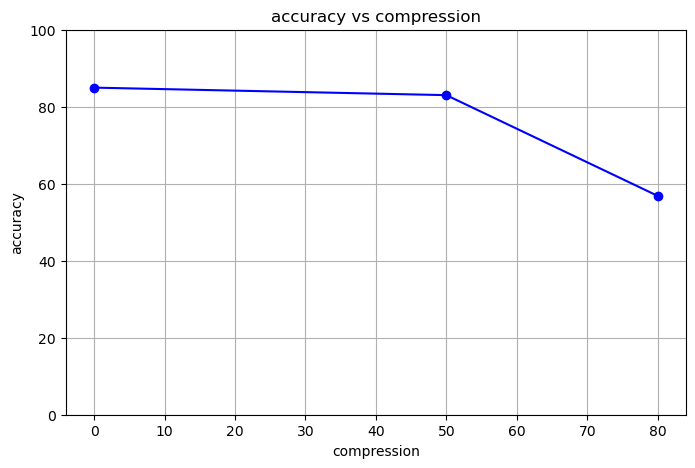

In [13]:
fine_tuned_model_20 = fine_tune_model(model_20, test_loader, epochs=3, device=device)
acc_recovered_20 = evaluate_model(fine_tuned_model_20, test_loader, device)
print(f"accuracy after finetuning 80% compressed model: {acc_recovered_20:.2f}% (previously: {acc_20:.2f}%)")

fine_tuned_model_50 = fine_tune_model(model_50, test_loader, epochs=3, device=device)
acc_recovered_50 = evaluate_model(fine_tuned_model_50, test_loader, device)
print(f"accuracy after finetuning 50% compressed model: {acc_recovered_50:.2f}% (previously: {acc_50:.2f}%)")

print("\nmeasuring inference speed ( on CPU )")
# random input batch
dummy_input = torch.randn(1, 3, 224, 224) 

time_base = measure_inference_speed(base_model, dummy_input, device='cpu')
time_compressed_50 = measure_inference_speed(fine_tuned_model_50, dummy_input, device='cpu')
time_compressed_20 = measure_inference_speed(fine_tuned_model_20, dummy_input, device='cpu')

print(f"base latency:   {time_base:.2f} ms")

print(f"50% compressed latency: {time_compressed_50:.2f} ms")
print(f"speedup: {time_base / time_compressed_50:.2f}x")

print(f"80% compressed latency: {time_compressed_20:.2f} ms")
print(f"speedup: {time_base / time_compressed_20:.2f}x")



rates = [0, 50, 80]
accuracies = [base_acc, acc_recovered_50, acc_recovered_20] 

plt.figure(figsize=(8, 5))
plt.plot(rates, accuracies, marker='o', linestyle='-', color='b')

plt.title("accuracy vs compression")
plt.xlabel("compression")
plt.ylabel("accuracy")
plt.ylim(0, 100)
plt.grid(True)
    
plt.show()


In [21]:
print("\nmeasuring inference speed ( on CPU ) 1000 repeats")
# random input batch
dummy_input = torch.randn(1, 3, 224, 224)

time_base = measure_inference_speed(base_model, dummy_input, device='cpu',repeats=1000)
time_compressed_50 = measure_inference_speed(fine_tuned_model_50, dummy_input, device='cpu',repeats=1000)
time_compressed_20 = measure_inference_speed(fine_tuned_model_20, dummy_input, device='cpu',repeats=1000)

print(f"base latency:   {time_base:.2f} ms")

print(f"50% compressed latency: {time_compressed_50:.2f} ms")
print(f"speedup: {time_base / time_compressed_50:.2f}x")

print(f"80% compressed latency: {time_compressed_20:.2f} ms")
print(f"speedup: {time_base / time_compressed_20:.2f}x")


measuring inference speed ( on CPU ) 1000 repeats
base latency:   53.80 ms
50% compressed latency: 40.97 ms
speedup: 1.31x
80% compressed latency: 48.88 ms
speedup: 1.10x


In [20]:
print("\nmeasuring inference speed ( on cuda ) 1000 repeats")
# random input batch
dummy_input = torch.randn(1, 3, 224, 224)

time_base = measure_inference_speed(base_model, dummy_input, device='cuda',repeats=1000)
time_compressed_50 = measure_inference_speed(fine_tuned_model_50, dummy_input, device='cuda',repeats=1000)
time_compressed_20 = measure_inference_speed(fine_tuned_model_20, dummy_input, device='cuda',repeats=1000)

print(f"base latency:   {time_base:.2f} ms")

print(f"50% compressed latency: {time_compressed_50:.2f} ms")
print(f"speedup: {time_base / time_compressed_50:.2f}x")

print(f"80% compressed latency: {time_compressed_20:.2f} ms")
print(f"speedup: {time_base / time_compressed_20:.2f}x")


measuring inference speed ( on cuda ) 1000 repeats
base latency:   2.47 ms
50% compressed latency: 2.42 ms
speedup: 1.02x
80% compressed latency: 2.41 ms
speedup: 1.03x


# step 4

In [ ]:
def cond_number_of_layer(weight_tensor):
    W = weight_tensor.detach().cpu().numpy()
    start_shape = W.shape
    if len(start_shape) > 2:
        W = W.reshape(start_shape[0], -1) 
    return np.linalg.cond(W)

print(f"condition number of selected middle layer: {cond_number_of_layer(intermediate_weights):.2f}")
print(f"condition number of final layer: {cond_number_of_layer(final_weights):.2f}")


condition number of selected middle layer: 6.68
condition number of middle layer: 28.51
